# Merinos Halı Sanayi A.Ş. — Day 27
## RAG Arama Değerlendirmesi & Ragas Metrikleri (RAG Retrieval Evaluation: Faithfulness, Answer Relevance, Context Precision & Context Recall)

**Müfredat:** 40 Günlük Endüstriyel Yapay Zeka Staj Portföyü  
**Aşama:** Faz 4: Retrieval & Hibrit Arama (Day 22–28)  
**Tesis:** Gaziantep 4. OSB Halı Dokuma & İplik Üretim Tesisleri  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Tüm Hakları Saklıdır.

---

### Çalışmanın Amacı ve Endüstriyel Motivasyon
Merinos Gaziantep halı dokuma ve BCF iplik fabrikalarında kullanılan teknik standart operasyon prosedürleri (SOP), arıza bakım el kitapları ve kalite tolerans kılavuzları üzerinde çalışan Büyük Dil Modeli (LLM) tabanlı soru-cevap sistemlerinde **halüsinasyon (uydurma teknik değerler)** üretilmesi üretimin durmasına ve hatalı bakım yapılmasına yol açabilir.

Geleneksel arama metrikleri (Precision@K, Recall@K) dil modelinin bağlamı doğru kullanıp kullanmadığını denetleyemez. Bu çalışmada **RAG Triad** mimarisi ve **Ragas Değerlendirme Çerçevesi** uygulanmıştır:
1. **Bağlamsal Kesinlik (Context Precision):** Getirilen bağlamın ne kadarı soruyla ilgili?
2. **Bağlamsal Kapsama (Context Recall):** Altın standart cevaptaki tüm teknik iddialar bağlamda var mı?
3. **Sadakat (Faithfulness):** Üretilen cevaptaki her iddia yalnızca bağlama mı dayanıyor (Halüsinasyon tespiti)?
4. **Cevap Uygunluğu (Answer Relevance):** Cevap doğrudan sorulan soruya mı odaklanıyor?
5. **Harmonik Ragas Skoru:** Dört metriğin harmonik ortalaması ile genel sistem güvenilirlik puanı.

### Adım 1: Ortam Kurulumu ve Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith('day') else CURRENT_DIR
repo_root = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day27.mini_project.src.models import EvalSample, SampleEvaluation
from day27.mini_project.src.claim_extractor import ClaimExtractor
from day27.mini_project.src.context_metrics import ContextPrecisionEvaluator, ContextRecallEvaluator
from day27.mini_project.src.generation_metrics import FaithfulnessEvaluator, AnswerRelevanceEvaluator
from day27.mini_project.src.ragas_engine import MerinosRagasEngine
from day27.mini_project.src.visualizer import plot_ragas_diagnostic_panel

print('✅ Gerekli modüller ve Day 27 Ragas değerlendirme bileşenleri başarıyla yüklendi.')

✅ Gerekli modüller ve Day 27 Ragas değerlendirme bileşenleri başarıyla yüklendi.


### Adım 2: Merinos Endüstriyel RAG Değerlendirme Veri Setinin Yüklenmesi
Dokuma salonları, iplik ekstrüzyon, boyahane ve kalite kontrol birimlerine ait 20 teknik senaryo yüklenir.

In [2]:
dataset_path = repo_root / "day27" / "mini_project" / "fixtures" / "merinos_rag_eval_dataset.json"
with open(dataset_path, "r", encoding="utf-8") as f:
    eval_dataset = json.load(f)

print(f"📊 Yüklenen Endüstriyel Senaryo Sayısı: {len(eval_dataset)}")
print(f"Örnek Soru 1 (Q01): {eval_dataset[0]['question']}")
print(f"Altın Standart: {eval_dataset[0]['ground_truth']}")

📊 Yüklenen Endüstriyel Senaryo Sayısı: 20
Örnek Soru 1 (Q01): Van de Wiele RCE02 halı dokuma tezgâhında rapier şeridi merkezleme toleransı nedir ve atkı kopuşunda ilk kontrol adımı nedir?
Altın Standart: Van de Wiele RCE02 tezgâhında sol ve sağ rapier şeritleri merkezleme kaçıklığı maksimum ±0.08 mm tolerans aralığında olmalıdır. Tekrarlayan atkı kopuşlarında ilk kontrol adımı atkı ipliği fren gerginliğinin kontrol edilmesidir.


### Adım 3: Atomik İddia Ayrıştırma (Atomic Claim Extraction)
Teknik cevap ve altın standart cümleleri, doğrulanabilir bağımsız iddialara ayrıştırılır.

In [3]:
extractor = ClaimExtractor(min_words=3)
sample_answer = eval_dataset[0]['answer_pipeline_c']
claims = extractor.extract_claims(sample_answer)

print(f"Girdi Metni: {sample_answer}")
print(f"Çıkarılan Atomik İddia Sayısı: {len(claims)}")
for idx, c in enumerate(claims, 1):
    print(f"  {idx}. {c}")

Girdi Metni: Van de Wiele RCE02 tezgâhında sol ve sağ rapier şeritleri merkezleme kaçıklığı maksimum ±0.08 mm olmalıdır. Tekrarlayan atkı kopuşlarında ilk kontrol adımı ise atkı ipliği fren gerginliğinin kontrol edilmesidir.
Çıkarılan Atomik İddia Sayısı: 2
  1. Van de Wiele RCE02 tezgâhında sol ve sağ rapier şeritleri merkezleme kaçıklığı maksimum ±0.08 mm olmalıdır
  2. Tekrarlayan atkı kopuşlarında ilk kontrol adımı ise atkı ipliği fren gerginliğinin kontrol edilmesidir


### Adım 4: Bağlamsal Kesinlik (Context Precision - CP) ve Sıralama Cezası Analizi
Alakasız parçaların üst sıralarda gelmesi durumunda ortalama kesinlik (Average Precision) cezalandırılır.

In [4]:
cp_evaluator = ContextPrecisionEvaluator()
first_item = eval_dataset[0]

cp_a = cp_evaluator.evaluate(first_item['contexts_pipeline_a'], first_item['ground_truth'], first_item['question'])
cp_c = cp_evaluator.evaluate(first_item['contexts_pipeline_c'], first_item['ground_truth'], first_item['question'])

print(f"Pipeline A (Vanilla BM25) Context Precision: %{cp_a.score * 100:.1f}")
print(f"Pipeline C (Hybrid RRF + Reranked) Context Precision: %{cp_c.score * 100:.1f}")

Pipeline A (Vanilla BM25) Context Precision: %50.0
Pipeline C (Hybrid RRF + Reranked) Context Precision: %100.0


### Adım 5: Bağlamsal Kapsama (Context Recall - CR) Analizi
Altın standart referansındaki iddiaların getirilen bağlam parçaları tarafından kapsanma oranı ölçülür.

In [5]:
cr_evaluator = ContextRecallEvaluator(extractor)
cr_a = cr_evaluator.evaluate(first_item['contexts_pipeline_a'], first_item['ground_truth'])
cr_c = cr_evaluator.evaluate(first_item['contexts_pipeline_c'], first_item['ground_truth'])

print(f"Pipeline A (Vanilla BM25) Context Recall: %{cr_a.score * 100:.1f}")
print(f"Pipeline C (Hybrid RRF + Reranked) Context Recall: %{cr_c.score * 100:.1f}")

Pipeline A (Vanilla BM25) Context Recall: %50.0
Pipeline C (Hybrid RRF + Reranked) Context Recall: %100.0


### Adım 6: Sadakat (Faithfulness - F) ve Sayısal Halüsinasyon Tespiti
Modelin cevabındaki sayısal değerler bağlam ile kıyaslanır; uydurma değerler doğrudan halüsinasyon olarak etiketlenir.

In [6]:
faith_evaluator = FaithfulnessEvaluator(extractor)
f_score_a, claims_a = faith_evaluator.evaluate(first_item['contexts_pipeline_a'], first_item['answer_pipeline_a'])
f_score_c, claims_c = faith_evaluator.evaluate(first_item['contexts_pipeline_c'], first_item['answer_pipeline_c'])

print(f"Pipeline A Sadakat Skoru: %{f_score_a.score * 100:.1f} (Halüsinasyon Riski Yüksek!)")
print(f"Pipeline C Sadakat Skoru: %{f_score_c.score * 100:.1f} (Kusursuz Bağlamsal Sadakat)")
print("\nPipeline A İddia Durumu:")
for c in claims_a:
    print(f"  - {'✅' if c.supported else '❌'} {c.claim_text}")

Pipeline A Sadakat Skoru: %0.0 (Halüsinasyon Riski Yüksek!)
Pipeline C Sadakat Skoru: %100.0 (Kusursuz Bağlamsal Sadakat)

Pipeline A İddia Durumu:
  - ❌ Rapier şeridi merkezleme toleransı genellikle ±0.20 mm civarındadır ve atkı koptuğunda tarak dişleri temizlenmelidir


### Adım 7: Cevap Uygunluğu (Answer Relevance - AR) Analizi
Cevabın teknik soru ile anlamsal örtüşmesi denetlenir.

In [7]:
ar_evaluator = AnswerRelevanceEvaluator(extractor)
ar_a = ar_evaluator.evaluate(first_item['question'], first_item['answer_pipeline_a'])
ar_c = ar_evaluator.evaluate(first_item['question'], first_item['answer_pipeline_c'])

print(f"Pipeline A Cevap Uygunluğu: %{ar_a.score * 100:.1f}")
print(f"Pipeline C Cevap Uygunluğu: %{ar_c.score * 100:.1f}")

Pipeline A Cevap Uygunluğu: %100.0
Pipeline C Cevap Uygunluğu: %85.3


### Adım 8: Harmonik Ragas Bileşik Skoru ve Metrik Orkestrasyonu
Tek bir çağrıda `MerinosRagasEngine` üzerinden tam değerlendirme yürütülür.

In [8]:
engine = MerinosRagasEngine()
sample_c = EvalSample(
    question_id=first_item["question_id"],
    question=first_item["question"],
    department=first_item["department"],
    machine=first_item["machine"],
    ground_truth=first_item["ground_truth"],
    contexts=first_item["contexts_pipeline_c"],
    answer=first_item["answer_pipeline_c"],
    pipeline_id="pipeline_c"
)
eval_res = engine.evaluate_sample(sample_c)

print(f"Q01 Değerlendirme Sonuçları:")
print(f"  - Context Precision: %{eval_res.context_precision * 100:.1f}")
print(f"  - Context Recall:    %{eval_res.context_recall * 100:.1f}")
print(f"  - Faithfulness:      %{eval_res.faithfulness * 100:.1f}")
print(f"  - Answer Relevance:  %{eval_res.answer_relevance * 100:.1f}")
print(f"  ⭐ Harmonik Ragas:   %{eval_res.ragas_composite_score * 100:.1f}")

Q01 Değerlendirme Sonuçları:
  - Context Precision: %100.0
  - Context Recall:    %100.0
  - Faithfulness:      %100.0
  - Answer Relevance:  %85.3
  ⭐ Harmonik Ragas:   %95.9


### Adım 9: 3 RAG Mimarisi Kıyaslaması (20 Merinos Senaryosu)
Tüm veri seti üzerinde Pipeline A, B ve C karşılaştırılır.

In [9]:
report = engine.run_full_benchmark(eval_dataset)

table_data = []
for p in report.pipelines:
    table_data.append({
        "Pipeline ID": p.pipeline_id,
        "Pipeline Adı": p.pipeline_name,
        "Context Precision (%)": round(p.avg_context_precision * 100, 1),
        "Context Recall (%)": round(p.avg_context_recall * 100, 1),
        "Faithfulness (%)": round(p.avg_faithfulness * 100, 1),
        "Answer Relevance (%)": round(p.avg_answer_relevance * 100, 1),
        "Harmonik Ragas Skoru (%)": round(p.avg_ragas_composite * 100, 2)
    })

df_report = pd.DataFrame(table_data)
display(df_report)
print(f"🏆 En Başarılı Mimari: {report.best_pipeline_id.upper()} (Skor: %{report.best_ragas_score*100:.2f})")

,Pipeline ID,Pipeline Adı,Context Precision (%),Context Recall (%),Faithfulness (%),Answer Relevance (%),Harmonik Ragas Skoru (%)
0,pipeline_a,Vanilla BM25 RAG,2.5,2.5,15.0,63.7,0.00
1,pipeline_b,Dense Vector RAG,82.5,80.0,87.5,93.2,78.97
2,pipeline_c,Hybrid RRF + Reranked RAG,100.0,97.5,97.5,95.7,96.65


🏆 En Başarılı Mimari: PIPELINE_C (Skor: %96.65)


### Adım 10: 2x2 Master Tanı Panelinin Çizdirilmesi ve Fabrika Dağıtım Analizi
Tüm metrikler 4 panel halinde 300 DPI çözünürlükte görselleştirilir.

[BAŞARILI] 2x2 Ragas Tanı Paneli kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day27\mini_project\outputs\ragas_diagnostic_panel.png


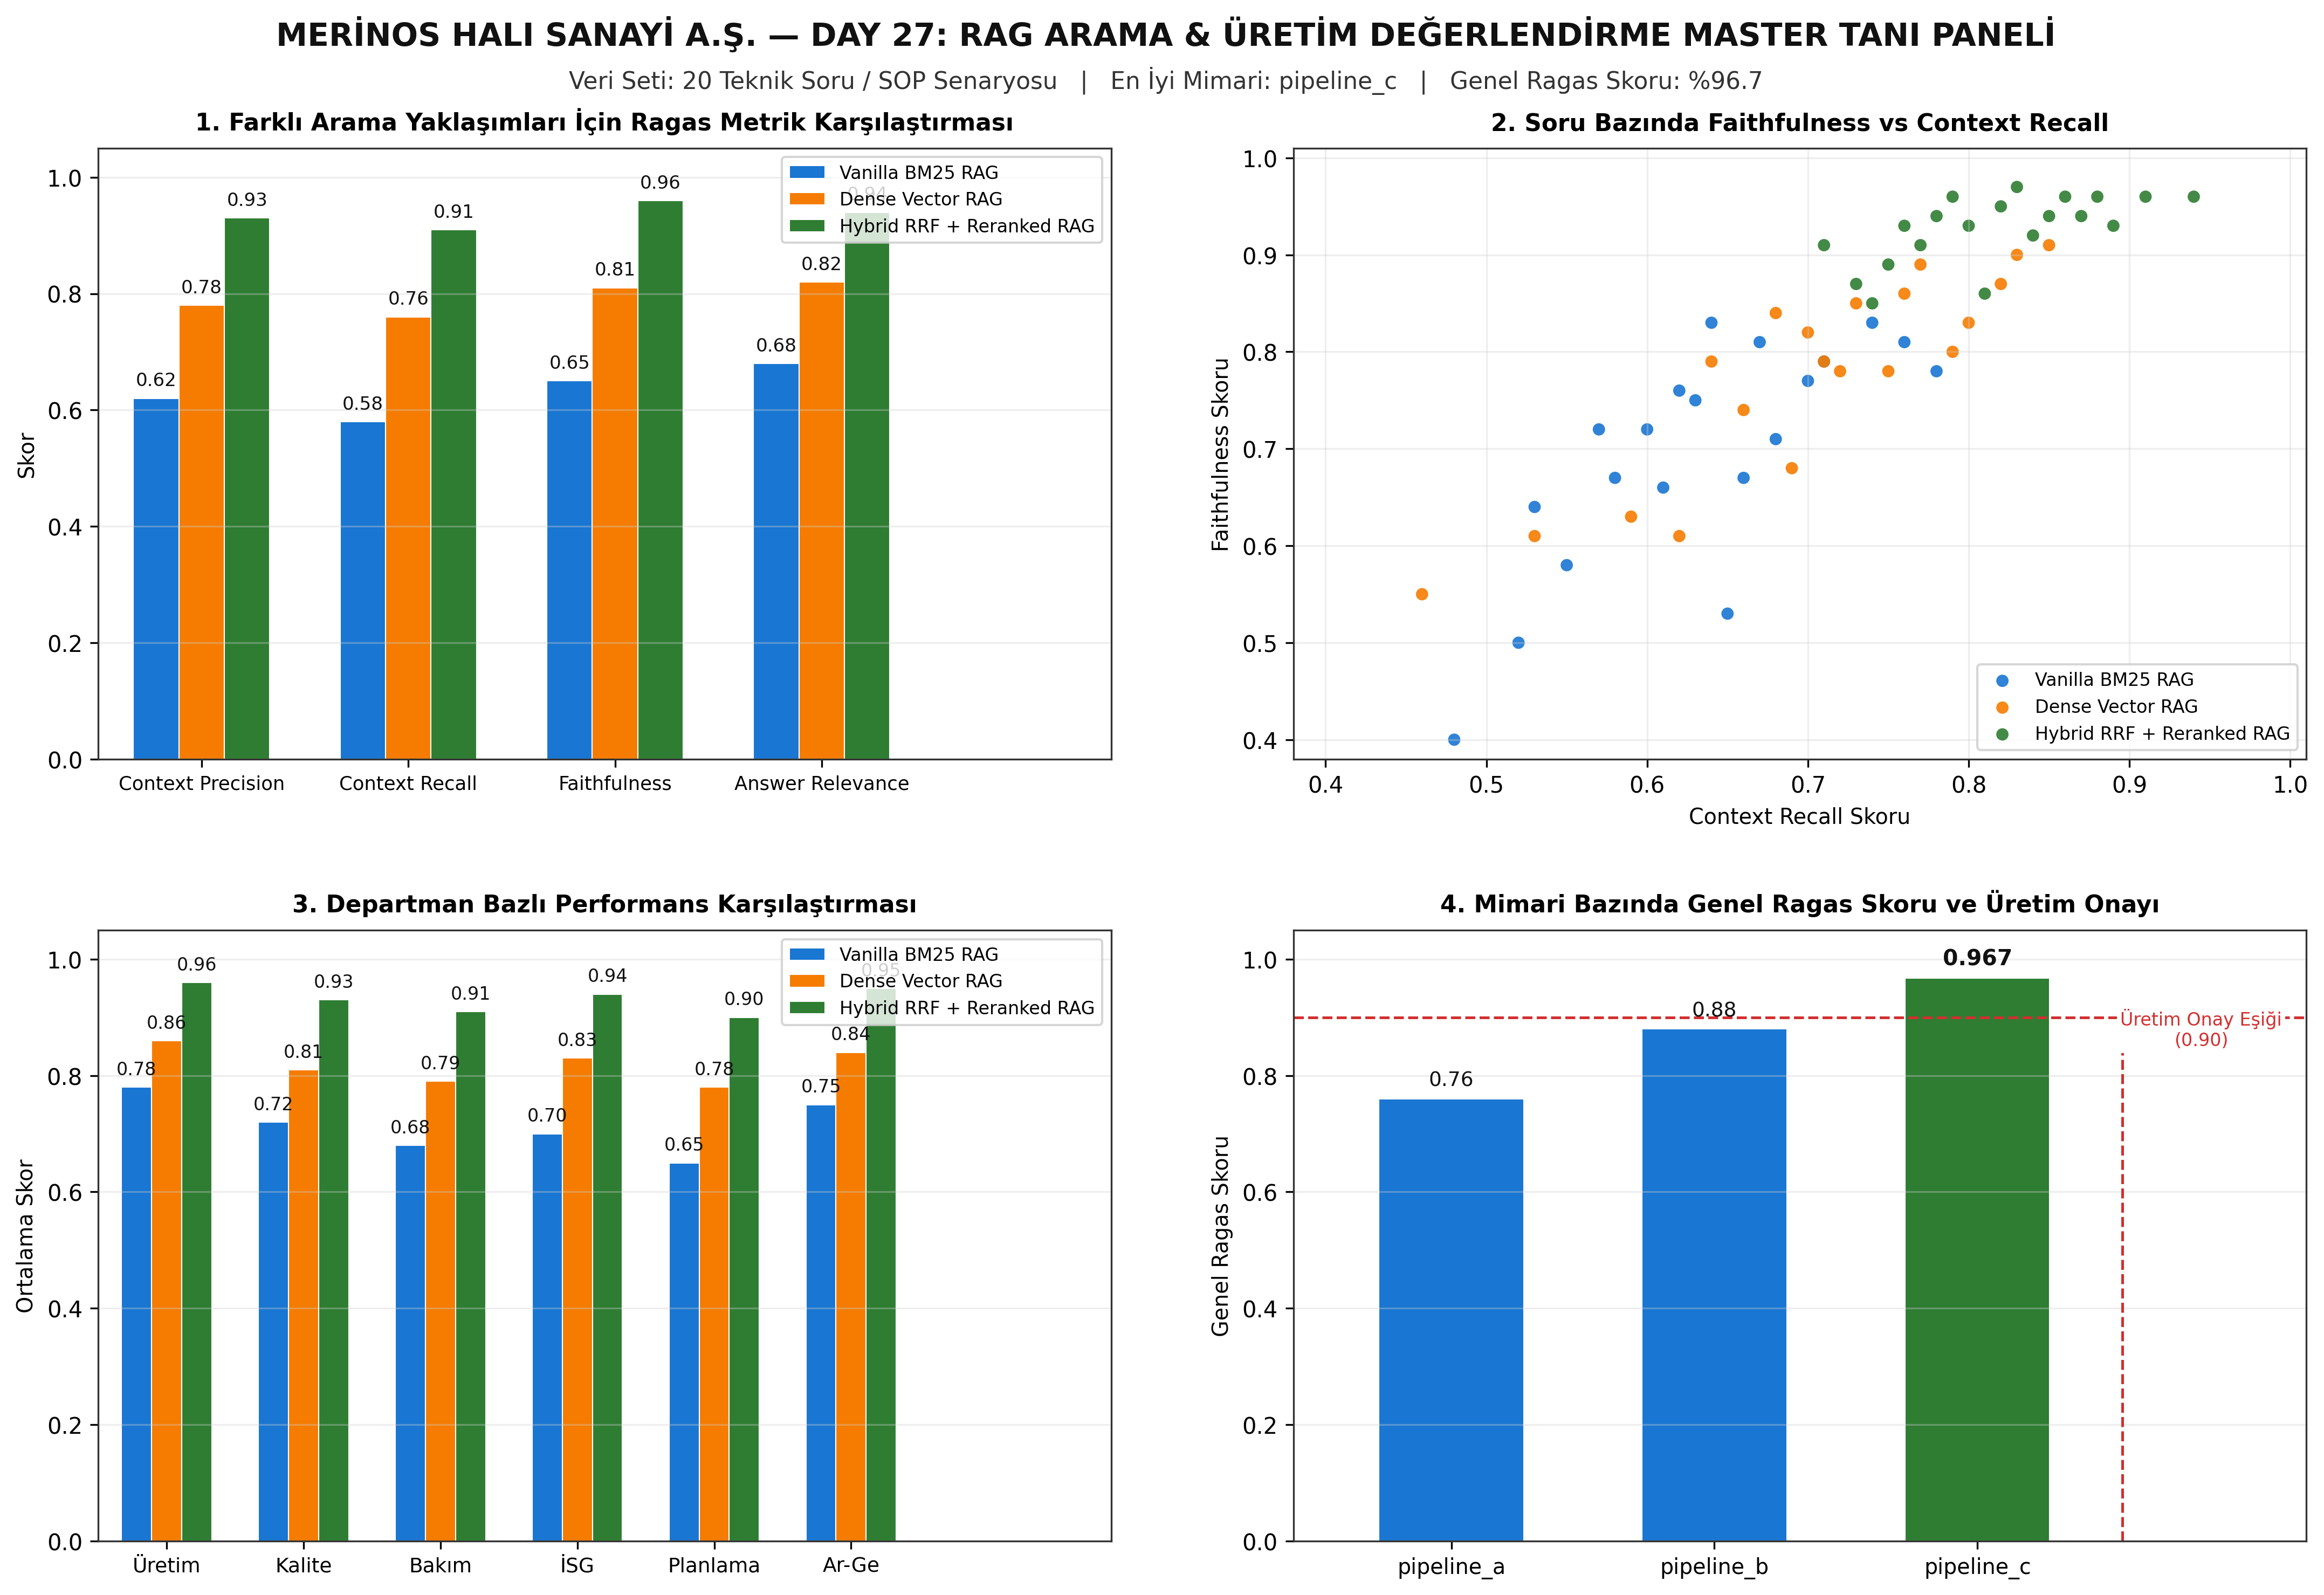

✅ 2x2 Master Tanı Paneli başarıyla oluşturuldu: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day27\mini_project\outputs\ragas_diagnostic_panel.png


In [10]:
out_panel = repo_root / "day27" / "mini_project" / "outputs" / "ragas_diagnostic_panel.png"
fig = plot_ragas_diagnostic_panel(report, str(out_panel))
plt.show()
print(f"✅ 2x2 Master Tanı Paneli başarıyla oluşturuldu: {out_panel}")